<a href="https://colab.research.google.com/github/NikhilGeorge01/ML-Prac/blob/main/MLAssignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
# Understanding of Cartpole
import gymnasium as gym
env = gym.make("CartPole-v1", render_mode="rgb_array")
for i_episode in range(5):
    obs, info = env.reset()
    t = 0
    done = False
    terminated = False
    truncated = False
    while not (terminated or truncated):
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        t += 1
        if terminated or truncated:
            print(f"Episode {i_episode+1} finished after {t} steps")
            break

env.close()


Episode 1 finished after 17 steps
Episode 2 finished after 16 steps
Episode 3 finished after 10 steps
Episode 4 finished after 25 steps
Episode 5 finished after 23 steps


In [13]:
#function to create various buckets
def bucketize(state_value):
    bucket_indices = []
    for i in range(len(state_value)):
        if state_value[i] <= state_value_bounds[i][0]:
            bucket_index = 0
        elif state_value[i] >= state_value_bounds[i][1]:
            bucket_index = no_buckets[i] - 1
        else:
            bound_width = state_value_bounds[i][1] - state_value_bounds[i][0]
            offset = (no_buckets[i] - 1) * state_value_bounds[i][0] / bound_width
            scaling = (no_buckets[i] - 1) / bound_width
            bucket_index = int(round(scaling * state_value[i] - offset))
        bucket_indices.append(bucket_index)
    return tuple(bucket_indices)


In [14]:
#way to select action
import random
import numpy as np
class DQNAgent:
  def select_action(self,state_value,explore_rate):
    if random.random() < explore_rate:
      action = env.action_space.sample()
    else:
      action = np.argmax(q_value_table[state_value])
    return action


In [15]:
#basic configuration
import math
import matplotlib.pyplot as plt

no_buckets = (1,1,6,3)
no_actions = env.action_space.n
state_value_bounds = list(zip(env.observation_space.low, env.observation_space.high))
state_value_bounds[1] = (-0.5,0.5)
state_value_bounds[3] = (-math.radians(50), math.radians(50))
q_value_table = np.zeros(no_buckets + (no_actions,))
min_explore_rate = 0.1; min_learning_rate = 0.1; max_episodes = 1000;
max_time_steps = 250; streak_to_end = 120; solved_time = 199; discount = 0.99;
no_streaks = 0
def select_explore_rate(x):
  return max(min_learning_rate, min(1.0, 1.0- math.log10((x+1)/25)))
def select_learning_rate(x):
 return max(min_learning_rate, min(1.0, 1.0- math.log10((x+1)/25)))



In [16]:
#q learning algo
import numpy as np

totaltime = 0
no_streaks = 0
dqa = DQNAgent()
for episode_no in range(max_episodes):
    explore_rate = select_explore_rate(episode_no)
    learning_rate = select_learning_rate(episode_no)

    observation, info = env.reset()
    previous_state_value = bucketize(observation)
    done = False
    truncated = False
    time_step = 0

    while not (done or truncated):
        action = dqa.select_action(previous_state_value, explore_rate)
        observation, reward_gain, done, truncated, info = env.step(action)
        state_value = bucketize(observation)
        best_q_value = np.max(q_value_table[state_value])
        q_value_table[previous_state_value][action] += learning_rate * (
            reward_gain + discount * best_q_value - q_value_table[previous_state_value][action]
        )
        previous_state_value = state_value
        time_step += 1

    if time_step >= solved_time:
        no_streaks += 1
    else:
        no_streaks = 0

    if no_streaks > streak_to_end:
        print(f'CartPole problem is solved after {episode_no} episodes.')
        break

env.close()


CartPole problem is solved after 467 episodes.


In [44]:
!pip install stable-baselines3[extra]


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.2/187.2 kB 7.0 MB/s eta 0:00:00


In [45]:
import gymnasium as gym
from stable_baselines3 import DQN

env = gym.make("CartPole-v1")

model = DQN(
    "MlpPolicy",
    env,
    learning_rate=1e-3,
    buffer_size=2000,
    learning_starts=1000,
    batch_size=64,
    gamma=0.99,
    exploration_fraction=0.1,
    exploration_final_eps=0.01,
    target_update_interval=1000,
    verbose=1
)

model.learn(total_timesteps=50000)


Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 13.5     |
|    ep_rew_mean      | 13.5     |
|    exploration_rate | 0.989    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 9414     |
|    time_elapsed     | 0        |
|    total_timesteps  | 54       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 23.4     |
|    ep_rew_mean      | 23.4     |
|    exploration_rate | 0.963    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 9288     |
|    time_elapsed     | 0        |
|    total_timesteps  | 187      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 21.8     |
|    ep_rew_mean      | 21.8     |
|    exploration_rate | 0.948    |
| time/               |          |
|    episodes       

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 21.1     |
|    ep_rew_mean      | 21.1     |
|    exploration_rate | 0.8      |
| time/               |          |
|    episodes         | 48       |
|    fps              | 1215     |
|    time_elapsed     | 0        |
|    total_timesteps  | 1011     |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 0.582    |
|    n_updates        | 2        |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 20.7     |
|    ep_rew_mean      | 20.7     |
|    exploration_rate | 0.787    |
| time/               |          |
|    episodes         | 52       |
|    fps              | 1211     |
|    time_elapsed     | 0        |
|    total_timesteps  | 1077     |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 0.222    |
|    n_updates      

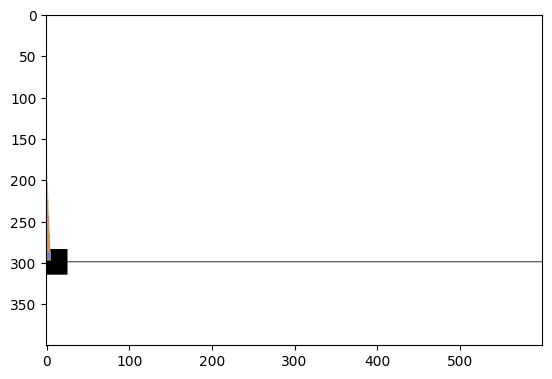

In [53]:
from IPython import display
import matplotlib.pyplot as plt

env = gym.make("CartPole-v1", render_mode="rgb_array")
obs, _ = env.reset()
done = False

while not done:
    frame = env.render()
    plt.imshow(frame)
    display.display(plt.gcf())
    display.clear_output(wait=True)

    action, _ = model.predict(obs)
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

env.close()


In [59]:
pip install stable-baselines3[extra]


In [62]:
pip install sb3-contrib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.2/93.2 kB 4.0 MB/s eta 0:00:00


In [64]:
from sb3_contrib import QRDQN
import gymnasium as gym

# Create the environment
env = gym.make("CartPole-v1")

# Define the policy kwargs
policy_kwargs = dict(n_quantiles=50)

# Initialize the model
model = QRDQN(
    "MlpPolicy",
    env,
    policy_kwargs=policy_kwargs,
    verbose=1
)

# Train the model
model.learn(total_timesteps=10000, log_interval=4)

# Save the model
model.save("qrdqn_cartpole")


Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 22       |
|    ep_rew_mean      | 22       |
|    exploration_rate | 0.01     |
| time/               |          |
|    episodes         | 4        |
|    fps              | 7414     |
|    time_elapsed     | 0        |
|    total_timesteps  | 88       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 16.2     |
|    ep_rew_mean      | 16.2     |
|    exploration_rate | 0.01     |
| time/               |          |
|    episodes         | 8        |
|    fps              | 497      |
|    time_elapsed     | 0        |
|    total_timesteps  | 130      |
| train/              |          |
|    learning_rate    | 5e-05    |
|    loss             | 12.8     |
|    n_updates        | 7        |
------------------------------

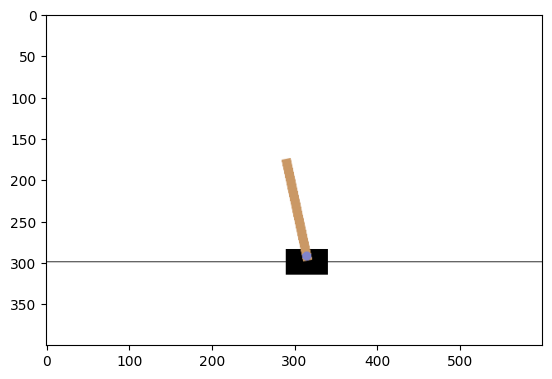

In [65]:
from IPython import display
import matplotlib.pyplot as plt

env = gym.make("CartPole-v1", render_mode="rgb_array")
obs, _ = env.reset()
done = False

while not done:
    frame = env.render()
    plt.imshow(frame)
    display.display(plt.gcf())
    display.clear_output(wait=True)

    action, _ = model.predict(obs)
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

env.close()
